<a href="https://colab.research.google.com/github/nbhide8/Bhargava-Lab-Project/blob/main/Barghava_Lab_Project_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Exploration

I imported the data from the National Cancer Institute's Imaging Data Commons.

**Initial Attempt:** turns out that I only downloaded a few patient's H&E slides, which were very high resolution.

**Second Attempt:** I used the NCI Imaging Data Commons (IDC) python library to import. Allowed me to see all data in aggregate.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

data_path = '/content/drive/MyDrive/TCGA_LUAD_DATA'
print(os.listdir(data_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['tcga_luad']


In [ ]:
sub_path = os.path.join(data_path, 'tcga_luad')
print(os.listdir(sub_path))

['TCGA-05-4244']


In [ ]:
case_path = os.path.join(sub_path, 'TCGA-05-4244')
print(os.listdir(case_path))

['2.25.317753984268209060558780446660059290395']


In [ ]:
series_path = os.path.join(case_path, '2.25.317753984268209060558780446660059290395')
files = os.listdir(series_path)
print(len(files))
print(files[:10])

8
['SM_1.3.6.1.4.1.5962.99.1.1068263875.756580321.1637450836419.2.0', 'SEG_1.2.826.0.1.3680043.10.511.3.79712183866234816171253053207180027', 'SEG_1.2.826.0.1.3680043.10.511.3.20329518875986184288440066502489091', 'SEG_1.2.826.0.1.3680043.10.511.3.18222880468009513997055669357208731', 'SM_1.3.6.1.4.1.5962.99.1.1042652702.25371455.1637425225246.2.0', 'SEG_1.2.826.0.1.3680043.10.511.3.12980541983296254259040082386336186', 'SM_1.3.6.1.4.1.5962.99.1.1073896398.1734330989.1637456468942.2.0', 'ANN_1.2.826.0.1.3680043.10.511.3.10724664324877593380040180842935308']


In [ ]:
for f in files:
    full = os.path.join(series_path, f)
    print(f, '-> dir' if os.path.isdir(full) else f'-> file ({os.path.getsize(full)} bytes)')

SM_1.3.6.1.4.1.5962.99.1.1068263875.756580321.1637450836419.2.0 -> dir
SEG_1.2.826.0.1.3680043.10.511.3.79712183866234816171253053207180027 -> dir
SEG_1.2.826.0.1.3680043.10.511.3.20329518875986184288440066502489091 -> dir
SEG_1.2.826.0.1.3680043.10.511.3.18222880468009513997055669357208731 -> dir
SM_1.3.6.1.4.1.5962.99.1.1042652702.25371455.1637425225246.2.0 -> dir
SEG_1.2.826.0.1.3680043.10.511.3.12980541983296254259040082386336186 -> dir
SM_1.3.6.1.4.1.5962.99.1.1073896398.1734330989.1637456468942.2.0 -> dir
ANN_1.2.826.0.1.3680043.10.511.3.10724664324877593380040180842935308 -> dir


In [ ]:
sm_path = os.path.join(series_path, 'SM_1.3.6.1.4.1.5962.99.1.1068263875.756580321.1637450836419.2.0')
sm_files = os.listdir(sm_path)
print(len(sm_files))
print(sm_files[:10])

4
['4e70c4a5-5237-4bc6-912e-4a4abe79dfa8.dcm', '450e14fd-d225-4b52-9926-6426fc1bf5e1.dcm', '75e3c8a3-8873-4439-8d81-987ac474d016.dcm', '889fc52c-4b18-422c-8053-e3ebfd9b854e.dcm']


In [ ]:
!pip install -q pydicom
import pydicom

dcm_path = os.path.join(sm_path, sm_files[0])
ds = pydicom.dcmread(dcm_path)
print(ds)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 44.8 MB/s eta 0:00:00
Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 222
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: VL Whole Slide Microscopy Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.5962.99.1.1068263875.756580321.1637450836419.8.0
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.5962.99.2
(0002,0013) Implementation Version Name         SH: 'PIXELMEDJAVA001'
(0002,0016) Source Application Entity Title     AE: 'OURAETITLE'
-------------------------------------------------
(0008,0008) Image Type                          CS: ['DERIVED', 'PRIMARY', 'VOLUME', 'NONE']
(0008,0012) Instance Creation Date              DA: '20220602'
(0008,0013) Instance Creation Time              TM: '23

In [ ]:
import os

sm_dirs = []
dcm_files = []
cases = set()

for root, dirs, fnames in os.walk(sub_path):
    parts = os.path.relpath(root, sub_path).split(os.sep)
    if len(parts) >= 1 and parts[0] != '.':
        cases.add(parts[0])
    for d in dirs:
        if d.startswith('SM_'):
            sm_dirs.append(os.path.join(root, d))
    for f in fnames:
        if f.endswith('.dcm'):
            dcm_files.append(os.path.join(root, f))

print("Cases (patients):", len(cases))
print("SM (slide) folders:", len(sm_dirs))
print("Total .dcm files:", len(dcm_files))

Cases (patients): 1
SM (slide) folders: 3
Total .dcm files: 19


In [ ]:
import pydicom

for sm_dir in sm_dirs:
    print(sm_dir)
    for f in os.listdir(sm_dir):
        ds = pydicom.dcmread(os.path.join(sm_dir, f), stop_before_pixels=True)
        print(f"  {f}: {ds.TotalPixelMatrixColumns}x{ds.TotalPixelMatrixRows}, "
              f"frames={ds.NumberOfFrames}, series_desc={ds.SeriesDescription}, "
              f"image_type={list(ds.ImageType)}")
    print()

/content/drive/MyDrive/TCGA_LUAD_DATA/tcga_luad/TCGA-05-4244/2.25.317753984268209060558780446660059290395/SM_1.3.6.1.4.1.5962.99.1.1068263875.756580321.1637450836419.2.0
  4e70c4a5-5237-4bc6-912e-4a4abe79dfa8.dcm: 22001x19330, frames=6536, series_desc=Frozen HE TP BS1, image_type=['DERIVED', 'PRIMARY', 'VOLUME', 'NONE']
  450e14fd-d225-4b52-9926-6426fc1bf5e1.dcm: 874x768, frames=1, series_desc=Frozen HE TP BS1, image_type=['DERIVED', 'PRIMARY', 'THUMBNAIL', 'RESAMPLED']
  75e3c8a3-8873-4439-8d81-987ac474d016.dcm: 2750x2416, frames=110, series_desc=Frozen HE TP BS1, image_type=['DERIVED', 'PRIMARY', 'VOLUME', 'RESAMPLED']
  889fc52c-4b18-422c-8053-e3ebfd9b854e.dcm: 5500x4832, frames=418, series_desc=Frozen HE TP BS1, image_type=['DERIVED', 'PRIMARY', 'VOLUME', 'RESAMPLED']

/content/drive/MyDrive/TCGA_LUAD_DATA/tcga_luad/TCGA-05-4244/2.25.317753984268209060558780446660059290395/SM_1.3.6.1.4.1.5962.99.1.1042652702.25371455.1637425225246.2.0
  501721a5-e125-47c2-b494-6123fea1ec32.dcm: 289

# Trying with python IDC Library

In [ ]:
!pip install -q idc-index

from idc_index import index
client = index.IDCClient()

df = client.index
print(df.shape)
print(df.columns.tolist())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.3/77.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 85.8 MB/s eta 0:00:00
(1032911, 31)
['collection_id', 'analysis_result_id', 'PatientID', 'SeriesInstanceUID', 'StudyInstanceUID', 'source_DOI', 'PatientAge', 'PatientSex', 'StudyDate', 'StudyDescription', 'BodyPartExamined', 'Modality', 'SOPClassUID', 'sop_class_name', 'TransferSyntaxUID', 'transfer_syntax_name', 'PhotometricInterpretation', 'PixelRepresentation', 'Manufacturer', 'ManufacturerModelName', 'SeriesDate', 'SeriesDescription', 'SeriesNumber', 'instanceCount', 'license_short_name', 'series_init_idc_version', 'series_revised_idc_version', 'aws_bucket', 'crdc_series_uuid', 'series_aws_url', 'series_size_MB']


In [ ]:
print(df['collection_id'].unique()[:20])
luad = df[df['collection_id'].str.contains('luad', case=False, na=False)]
print(luad['collection_id'].unique())
print(luad.shape)

['4d_lung' 'acrin_6698' 'acrin_contralateral_breast_mr' 'acrin_flt_breast'
 'acrin_nsclc_fdg_pet' 'adrenal_acc_ki67_seg'
 'advanced_mri_breast_lesions' 'anti_pd_1_lung' 'b_mode_and_ceus_liver'
 'bonemarrowwsi_pediatricleukemia' 'breast_cancer_screening_dbt'
 'breast_diagnosis' 'breast_mri_nact_pilot' 'c4kc_kits' 'catch'
 'cbis_ddsm' 'cc_radiomics_phantom' 'cc_radiomics_phantom_2'
 'cc_radiomics_phantom_3' 'cc_tumor_heterogeneity']
['cptac_luad' 'tcga_luad']
(6453, 31)


In [ ]:
tcga_luad_sm = df[(df['collection_id'] == 'tcga_luad') & (df['Modality'] == 'SM')]
print("SM series:", tcga_luad_sm.shape[0])
print("Unique patients:", tcga_luad_sm['PatientID'].nunique())
print(tcga_luad_sm['series_size_MB'].describe())
print("Total size (GB):", tcga_luad_sm['series_size_MB'].sum() / 1024)

SM series: 1608
Unique patients: 522
count    1608.000000
mean      401.912645
std       525.582169
min         7.717286
25%        96.103474
50%       180.246187
75%       442.742825
max      4190.478418
Name: series_size_MB, dtype: float64
Total size (GB): 631.1284505253907


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

data_path = '/content/drive/MyDrive/TCGA_LUAD_DATA'
sub_path = os.path.join(data_path, 'tcga_luad')
case_path = os.path.join(sub_path, 'TCGA-05-4244')
series_path = os.path.join(case_path, '2.25.317753984268209060558780446660059290395')

all_items = os.listdir(series_path)
seg_dirs = [os.path.join(series_path, f) for f in all_items if f.startswith('SEG_')]
ann_dirs = [os.path.join(series_path, f) for f in all_items if f.startswith('ANN_')]
print(seg_dirs)
print(ann_dirs)

Mounted at /content/drive
['/content/drive/MyDrive/TCGA_LUAD_DATA/tcga_luad/TCGA-05-4244/2.25.317753984268209060558780446660059290395/SEG_1.2.826.0.1.3680043.10.511.3.79712183866234816171253053207180027', '/content/drive/MyDrive/TCGA_LUAD_DATA/tcga_luad/TCGA-05-4244/2.25.317753984268209060558780446660059290395/SEG_1.2.826.0.1.3680043.10.511.3.18222880468009513997055669357208731', '/content/drive/MyDrive/TCGA_LUAD_DATA/tcga_luad/TCGA-05-4244/2.25.317753984268209060558780446660059290395/SEG_1.2.826.0.1.3680043.10.511.3.12980541983296254259040082386336186', '/content/drive/MyDrive/TCGA_LUAD_DATA/tcga_luad/TCGA-05-4244/2.25.317753984268209060558780446660059290395/SEG_1.2.826.0.1.3680043.10.511.3.20329518875986184288440066502489091']
['/content/drive/MyDrive/TCGA_LUAD_DATA/tcga_luad/TCGA-05-4244/2.25.317753984268209060558780446660059290395/ANN_1.2.826.0.1.3680043.10.511.3.10724664324877593380040180842935308']


In [ ]:
!pip install -q pydicom
import pydicom

for seg_dir in seg_dirs:
    seg_file = os.listdir(seg_dir)[0]
    ds = pydicom.dcmread(os.path.join(seg_dir, seg_file), stop_before_pixels=True)
    print(seg_dir.split('/')[-1])
    print("  SeriesDescription:", ds.get('SeriesDescription'))
    print("  Modality:", ds.Modality)
    print("  SOPClassUID:", ds.SOPClassUID)
    if 'SegmentSequence' in ds:
        for seg in ds.SegmentSequence:
            print("  Segment:", seg.get('SegmentLabel'), "|", seg.get('SegmentDescription'))
    print()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.5 MB/s eta 0:00:00
SEG_1.2.826.0.1.3680043.10.511.3.79712183866234816171253053207180027
  SeriesDescription: Stony Brook Inception-V4 Fractional TIL Map
  Modality: SEG
  SOPClassUID: 1.2.840.10008.5.1.4.1.1.66.4
  Segment: TILs Present | None

SEG_1.2.826.0.1.3680043.10.511.3.18222880468009513997055669357208731
  SeriesDescription: Stony Brook Inception-V4 Binary TIL Map
  Modality: SEG
  SOPClassUID: 1.2.840.10008.5.1.4.1.1.66.4
  Segment: TILs Present | None

SEG_1.2.826.0.1.3680043.10.511.3.12980541983296254259040082386336186
  SeriesDescription: Stony Brook CNN-generated TIL Map
  Modality: SEG
  SOPClassUID: 1.2.840.10008.5.1.4.1.1.66.4
  Segment: TILs Absent | None
  Segment: TILs Present | None

SEG_1.2.826.0.1.3680043.10.511.3.20329518875986184288440066502489091
  SeriesDescription: None
  Modality: SEG
  SOPClassUID: 1.2.840.10008.5.1.4.1.1.66.4
  Segment: Nuclei | None



In [ ]:
ann_file = os.listdir(ann_dirs[0])[0]
ds = pydicom.dcmread(os.path.join(ann_dirs[0], ann_file))
print("SeriesDescription:", ds.get('SeriesDescription'))
print("Modality:", ds.Modality)
print("SOPClassUID:", ds.SOPClassUID, "->", ds.get('sop_class_name', ''))
print(ds.get('ContentDescription'))
print(ds.get('ContentCreatorName'))

# Annotation-specific fields
if 'AnnotationGroupSequence' in ds:
    for grp in ds.AnnotationGroupSequence:
        print("  Group:", grp.get('AnnotationGroupLabel'), "|", grp.get('AnnotationGroupDescription'),
              "| NumberOfAnnotations:", grp.get('NumberOfAnnotations'))

SeriesDescription: None
Modality: ANN
SOPClassUID: 1.2.840.10008.5.1.4.1.1.91.1 -> 


  Group: Nuclei | None | NumberOfAnnotations: 194137


In [ ]:
!pip install -q idc-index
from idc_index import index
client = index.IDCClient()
df = client.index

tcga_luad_seg = df[(df['collection_id'] == 'tcga_luad') & (df['Modality'] == 'SEG')]
print(tcga_luad_seg.shape)
print(tcga_luad_seg['SeriesDescription'].value_counts(dropna=False))
print(tcga_luad_seg['analysis_result_id'].value_counts(dropna=False))

(2085, 31)
SeriesDescription
None                                                         551
Stony Brook CNN-generated TIL Map                            540
Stony Brook Inception-V4 Binary TIL Map                      479
Stony Brook Inception-V4 Fractional TIL Map                  479
AIMI lung and FDG tumor AI segmentation                       20
AIMI lung and nodule AI segmentation                          13
AIMI lung and nodule radiologist 2 corrected segmentation      2
AIMI lung and nodule radiologist 1 corrected segmentation      1
Name: count, dtype: int64
analysis_result_id
tcga_sbu_til_maps              1498
pan_cancer_nuclei_seg_dicom     551
bamf_aimi_annotations            36
Name: count, dtype: int64


In [ ]:
til_maps = df[(df['collection_id'] == 'tcga_luad') & (df['analysis_result_id'] == 'tcga_sbu_til_maps')]
print("TIL map series:", til_maps.shape[0])
print("Unique patients with TIL maps:", til_maps['PatientID'].nunique())

sm_patients = set(df[(df['collection_id'] == 'tcga_luad') & (df['Modality'] == 'SM')]['PatientID'])
til_patients = set(til_maps['PatientID'])
print("Patients with both SM slides and TIL maps:", len(sm_patients & til_patients))

TIL map series: 1498
Unique patients with TIL maps: 478
Patients with both SM slides and TIL maps: 478


# Building download manifest

count     478.000000
mean     1314.647219
std      1189.438361
min        73.236550
25%       514.519657
50%       987.508835
75%      1693.631890
max      7980.197822
Name: series_size_MB, dtype: float64


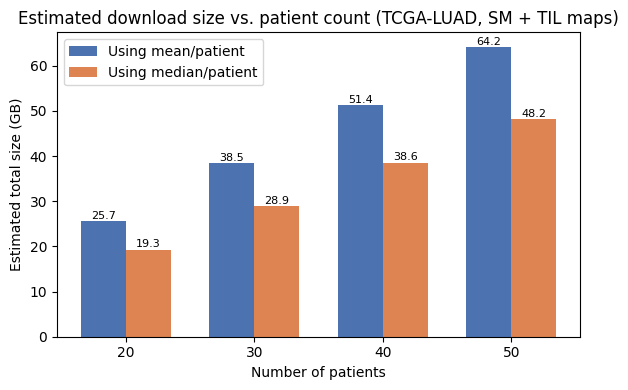

Mean-based (GB): {20: '25.7', 30: '38.5', 40: '51.4', 50: '64.2'}
Median-based (GB): {20: '19.3', 30: '28.9', 40: '38.6', 50: '48.2'}


In [ ]:
import matplotlib.pyplot as plt

eligible = til_patients  # patients with both SM slides and TIL maps
per_patient_sm = df[(df['collection_id'] == 'tcga_luad') & (df['Modality'] == 'SM') & (df['PatientID'].isin(eligible))] \
    .groupby('PatientID')['series_size_MB'].sum()
per_patient_til = til_maps.groupby('PatientID')['series_size_MB'].sum()
per_patient_total = (per_patient_sm + per_patient_til).sort_values()

print(per_patient_total.describe())

Ns = [20, 30, 40, 50]
avg_totals_gb = [per_patient_total.mean() * n / 1024 for n in Ns]
median_totals_gb = [per_patient_total.median() * n / 1024 for n in Ns]

fig, ax = plt.subplots(figsize=(6, 4))
x = range(len(Ns))
width = 0.35
ax.bar([i - width/2 for i in x], avg_totals_gb, width, label='Using mean/patient', color='#4C72B0')
ax.bar([i + width/2 for i in x], median_totals_gb, width, label='Using median/patient', color='#DD8452')
ax.set_xticks(list(x))
ax.set_xticklabels([str(n) for n in Ns])
ax.set_ylabel('Estimated total size (GB)')
ax.set_xlabel('Number of patients')
ax.set_title('Estimated download size vs. patient count (TCGA-LUAD, SM + TIL maps)')
ax.legend()
for i, v in enumerate(avg_totals_gb):
    ax.text(i - width/2, v + 0.5, f"{v:.1f}", ha='center', fontsize=8)
for i, v in enumerate(median_totals_gb):
    ax.text(i + width/2, v + 0.5, f"{v:.1f}", ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('/content/patient_size_chart.png', dpi=150)
plt.show()

print("Mean-based (GB):", dict(zip(Ns, [f'{v:.1f}' for v in avg_totals_gb])))
print("Median-based (GB):", dict(zip(Ns, [f'{v:.1f}' for v in median_totals_gb])))

In [ ]:
sm_luad = df[(df['collection_id'] == 'tcga_luad') & (df['Modality'] == 'SM')].copy()

def specimen_type(desc):
    if not isinstance(desc, str):
        return 'Unknown'
    if 'FFPE' in desc:
        return 'FFPE'
    if 'Frozen' in desc:
        return 'Frozen'
    return 'Other'

sm_luad['specimen_type'] = sm_luad['SeriesDescription'].apply(specimen_type)

print(sm_luad.groupby('specimen_type')['series_size_MB'].describe())
print()
print("Correlation between instanceCount (frames) and size:",
      sm_luad['instanceCount'].corr(sm_luad['series_size_MB']))

                count        mean         std        min        25%  \
specimen_type                                                         
FFPE            541.0  785.586891  645.629196   7.717286  258.51428   
Frozen         1067.0  207.378655  304.443081  17.253328   77.14880   

                      50%          75%          max  
specimen_type                                        
FFPE           627.684598  1182.595982  4190.478418  
Frozen         128.788458   221.921868  3160.481918  

Correlation between instanceCount (frames) and size: 0.5890854740574657


In [ ]:
ffpe_sm = sm_luad[sm_luad['specimen_type'] == 'FFPE']
ffpe_patients = set(ffpe_sm['PatientID'])

print("Patients with an FFPE SM slide:", len(ffpe_patients))
print("Patients with FFPE slide AND TIL map:", len(ffpe_patients & til_patients))

# Per-patient size if we only take FFPE slides (one diagnostic slide per patient, typically)
ffpe_eligible = ffpe_patients & til_patients
per_patient_ffpe = ffpe_sm[ffpe_sm['PatientID'].isin(ffpe_eligible)].groupby('PatientID')['series_size_MB'].sum()
per_patient_ffpe_til = til_maps[til_maps['PatientID'].isin(ffpe_eligible)].groupby('PatientID')['series_size_MB'].sum()
per_patient_ffpe_total = (per_patient_ffpe + per_patient_ffpe_til).dropna()

print()
print(per_patient_ffpe_total.describe())

Patients with an FFPE SM slide: 478
Patients with FFPE slide AND TIL map: 478

count     478.000000
mean      889.375200
std       998.947606
min         7.754028
25%       230.817443
50%       561.853948
75%      1215.813563
max      7540.925512
Name: series_size_MB, dtype: float64


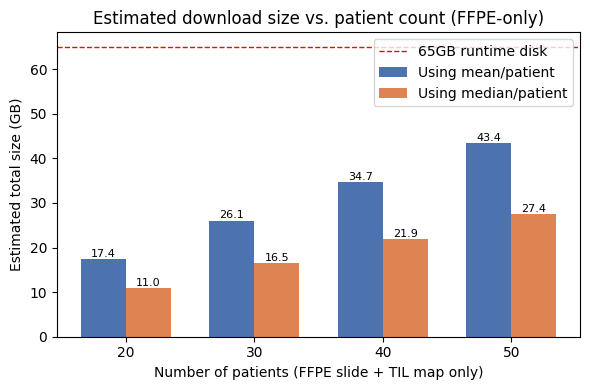

Mean-based (GB): {20: '17.4', 30: '26.1', 40: '34.7', 50: '43.4'}
Median-based (GB): {20: '11.0', 30: '16.5', 40: '21.9', 50: '27.4'}


In [ ]:
Ns = [20, 30, 40, 50]
mean_gb = [per_patient_ffpe_total.mean() * n / 1024 for n in Ns]
median_gb = [per_patient_ffpe_total.median() * n / 1024 for n in Ns]

fig, ax = plt.subplots(figsize=(6, 4))
x = range(len(Ns))
width = 0.35
ax.bar([i - width/2 for i in x], mean_gb, width, label='Using mean/patient', color='#4C72B0')
ax.bar([i + width/2 for i in x], median_gb, width, label='Using median/patient', color='#DD8452')
ax.axhline(65, color='red', linestyle='--', linewidth=1, label='65GB runtime disk')
ax.set_xticks(list(x))
ax.set_xticklabels([str(n) for n in Ns])
ax.set_ylabel('Estimated total size (GB)')
ax.set_xlabel('Number of patients (FFPE slide + TIL map only)')
ax.set_title('Estimated download size vs. patient count (FFPE-only)')
ax.legend()
for i, v in enumerate(mean_gb):
    ax.text(i - width/2, v + 0.5, f"{v:.1f}", ha='center', fontsize=8)
for i, v in enumerate(median_gb):
    ax.text(i + width/2, v + 0.5, f"{v:.1f}", ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('/content/patient_size_chart_ffpe.png', dpi=150)
plt.show()

print("Mean-based (GB):", dict(zip(Ns, [f'{v:.1f}' for v in mean_gb])))
print("Median-based (GB):", dict(zip(Ns, [f'{v:.1f}' for v in median_gb])))

# Validating pipeline